# Notebook 05 — Modelling
**Olist Delivery Delay Prediction | Capstone Project**


This notebook:
1. Loads the feature matrix from
2. Builds Classification models → predict `is_late`
3. Builds Regression models → predict `delay_gap` (days late)
4. Checks overfitting for every model
5. Combines both into a **Risk Score** preview

---
## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
    average_precision_score, mean_squared_error, r2_score, mean_absolute_error)
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Ready.')

Ready.


---
## 1 — Load Data

In [3]:
PATH = '/content/drive/MyDrive/Colab Notebooks/Olist/data/'

df = pd.read_csv(PATH + 'olist_features.csv')

---
## 2 — Regression Target

`delay_gap` = actual delivery − estimated delivery (in days).
Positive = late. We derive it here from the merged file because the raw timestamps
were correctly removed from NB04 (they would be leakage as *features*).
As a **target variable** it is safe to use.

In [4]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date', 'max_shipping_limit_date',
             'min_shipping_limit_date']

df_merged = pd.read_csv(PATH + 'olist_merged.csv', parse_dates=date_cols)

delay_gap = (
    df_merged['order_delivered_customer_date'] - df_merged['order_estimated_delivery_date']
).dt.days.values[:len(df)]

delay_gap = pd.Series(delay_gap, name='delay_gap')
print(f'delay_gap: mean={delay_gap.mean():.1f} d | median={delay_gap.median():.0f} d')
print(f'Late orders (gap > 0): {(delay_gap > 0).mean()*100:.1f}%')

delay_gap: mean=-11.9 d | median=-12 d
Late orders (gap > 0): 6.8%


---
## 3 — Features & Targets

In [5]:
# Leakage guard — these must NOT be in X
for col in ['delivery_days', 'delivery_status', 'review_score',
            'order_delivered_customer_date', 'carrier_handling_days']:
    assert col not in df.columns, f'LEAKAGE: {col} found!'
print('Leakage check passed.')

X       = df.drop(columns=['is_late'])
y_class = df['is_late']          # classification target
y_reg   = delay_gap              # regression target

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

print(f'Features: {X.shape[1]} ({len(num_cols)} numeric, {len(cat_cols)} categorical)')
print(f'Categorical cols: {cat_cols}')

Leakage check passed.
Features: 54 (49 numeric, 5 categorical)
Categorical cols: ['customer_state', 'payment_type', 'bottleneck_seller_state', 'dominant_category_group', 'purchase_hour_bucket']


---
## 4 — Shared Preprocessing Pipeline

In [6]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_cols),
], remainder='drop')

print('Preprocessor ready.')

Preprocessor ready.


---
## 5 — Time-Based Train / Test Split

We split by position (oldest 80% → train, newest 20% → test) to simulate
real deployment — a model must only predict *future* orders, not past ones.
Random splitting would be too optimistic here.

In [7]:
split = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train_c, y_test_c = y_class.iloc[:split], y_class.iloc[split:]
y_train_r, y_test_r = y_reg.iloc[:split],   y_reg.iloc[split:]

print(f'Train: {len(X_train):,} rows | Late: {y_train_c.mean()*100:.1f}%')
print(f'Test : {len(X_test):,} rows  | Late: {y_test_c.mean()*100:.1f}%')

Train: 77,164 rows | Late: 8.1%
Test : 19,291 rows  | Late: 8.3%


---
## 6 — Overfitting Check Helper

For every model we compare **train score vs test score**.
A large gap means the model memorised training data instead of generalising.

- AUC gap < 0.05 → ✅ Good
- AUC gap 0.05–0.10 → ⚠️ Mild
- AUC gap > 0.10 → ❌ Overfit

In [8]:
def overfit_check(name, model, X_tr, y_tr, X_te, y_te, task='clf'):
    if task == 'clf':
        tr_score = roc_auc_score(y_tr, model.predict_proba(X_tr)[:,1])
        te_score = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
        metric   = 'ROC-AUC'
    else:
        tr_score = r2_score(y_tr, model.predict(X_tr))
        te_score = r2_score(y_te, model.predict(X_te))
        metric   = 'R²'

    gap = tr_score - te_score
    verdict = ('✅ Good' if gap < 0.05 else '⚠️ Mild overfit' if gap < 0.10 else '❌ Overfit')
    print(f'{name:<28} Train {metric}: {tr_score:.4f} | Test {metric}: {te_score:.4f} | Gap: {gap:+.4f}  {verdict}')
    return {'name': name, 'train': tr_score, 'test': te_score, 'gap': gap}

print('Helper defined.')

Helper defined.


---
## 7 — Classification Models

Target: `is_late` (1 = late, 0 = on-time)

> **Class imbalance (from NB03):** only 8.1% of orders are late (11:1 ratio).
> We use `class_weight='balanced'` so models don't just predict "on-time" always.
> We evaluate using F1 + ROC-AUC, not accuracy.

### 7a — Logistic Regression (Baseline)

In [9]:
log_clf = Pipeline([
    ('pre',   preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
log_clf.fit(X_train, y_train_c)

y_pred  = log_clf.predict(X_test)
y_proba = log_clf.predict_proba(X_test)[:,1]
print(classification_report(y_test_c, y_pred, target_names=['On-time','Late']))
print(f'ROC-AUC: {roc_auc_score(y_test_c, y_proba):.4f}')
log_diag = overfit_check('Logistic Regression', log_clf, X_train, y_train_c, X_test, y_test_c)


              precision    recall  f1-score   support

     On-time       0.96      0.68      0.79     17696
        Late       0.16      0.66      0.25      1595

    accuracy                           0.67     19291
   macro avg       0.56      0.67      0.52     19291
weighted avg       0.89      0.67      0.75     19291

ROC-AUC: 0.7258
Logistic Regression          Train ROC-AUC: 0.7307 | Test ROC-AUC: 0.7258 | Gap: +0.0049  ✅ Good


### 7b — Random Forest Classifier

In [10]:
rf_clf = Pipeline([
    ('pre',   preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=20,
        class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_clf.fit(X_train, y_train_c)

y_pred  = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:,1]
print(classification_report(y_test_c, y_pred, target_names=['On-time','Late']))
print(f'ROC-AUC: {roc_auc_score(y_test_c, y_proba):.4f}')
rf_diag = overfit_check('Random Forest Clf', rf_clf, X_train, y_train_c, X_test, y_test_c)

              precision    recall  f1-score   support

     On-time       0.96      0.78      0.86     17696
        Late       0.20      0.60      0.30      1595

    accuracy                           0.77     19291
   macro avg       0.58      0.69      0.58     19291
weighted avg       0.89      0.77      0.81     19291

ROC-AUC: 0.7558
Random Forest Clf            Train ROC-AUC: 0.8061 | Test ROC-AUC: 0.7558 | Gap: +0.0503  ⚠️ Mild overfit


### 7c — XGBoost Classifier

In [11]:
spw = (y_train_c == 0).sum() / (y_train_c == 1).sum()  # ~11
print(f'scale_pos_weight = {spw:.1f}')

xgb_clf = Pipeline([
    ('pre',   preprocessor),
    ('model', XGBClassifier(
        n_estimators=200, max_depth=5, min_child_weight=10, gamma=1, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=42, n_jobs=-1))
])
xgb_clf.fit(X_train, y_train_c)

y_pred  = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:,1]
print(classification_report(y_test_c, y_pred, target_names=['On-time','Late']))
print(f'ROC-AUC: {roc_auc_score(y_test_c, y_proba):.4f}')
xgb_diag = overfit_check('XGBoost Clf', xgb_clf, X_train, y_train_c, X_test, y_test_c)

scale_pos_weight = 11.4
              precision    recall  f1-score   support

     On-time       0.96      0.78      0.86     17696
        Late       0.22      0.66      0.33      1595

    accuracy                           0.77     19291
   macro avg       0.59      0.72      0.59     19291
weighted avg       0.90      0.77      0.82     19291

ROC-AUC: 0.7996
XGBoost Clf                  Train ROC-AUC: 0.8503 | Test ROC-AUC: 0.7996 | Gap: +0.0508  ⚠️ Mild overfit


### Classification Summary

In [12]:
print('\n=== CLASSIFICATION SUMMARY ===')
print(f'{"Model":<28} {"Train AUC":>10} {"Test AUC":>10} {"Gap":>8}')
print('-'*60)
for d in [log_diag, rf_diag, xgb_diag]:
    print(f'{d["name"]:<28} {d["train"]:>10.4f} {d["test"]:>10.4f} {d["gap"]:>+8.4f}')
print('\nProposal targets: ROC-AUC > 0.80 | F1 (late) > 0.75')


=== CLASSIFICATION SUMMARY ===
Model                         Train AUC   Test AUC      Gap
------------------------------------------------------------
Logistic Regression              0.7307     0.7258  +0.0049
Random Forest Clf                0.8061     0.7558  +0.0503
XGBoost Clf                      0.8503     0.7996  +0.0508

Proposal targets: ROC-AUC > 0.80 | F1 (late) > 0.75


### Precision-Recall Curves

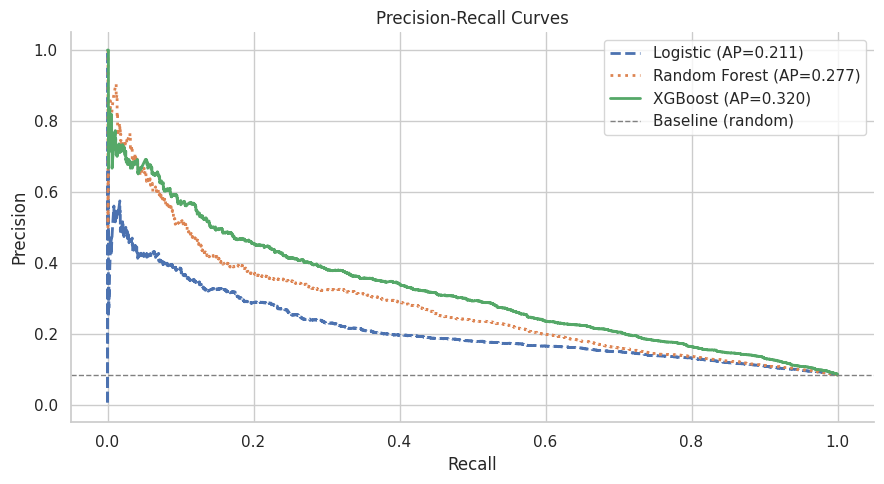

In [13]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(9, 5))
for name, clf, ls in [('Logistic', log_clf, '--'), ('Random Forest', rf_clf, ':'), ('XGBoost', xgb_clf, '-')]:
    p, r, _ = precision_recall_curve(y_test_c, clf.predict_proba(X_test)[:,1])
    ap = average_precision_score(y_test_c, clf.predict_proba(X_test)[:,1])
    ax.plot(r, p, lw=2, ls=ls, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test_c.mean(), ls='--', color='grey', lw=1, label='Baseline (random)')
ax.set_title('Precision-Recall Curves')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## 8 — Regression Models

Target: `delay_gap` (days late)
Proposal targets: **RMSE < 2 days** | **R² > 0.60**

### 8a — Linear Regression (Baseline)

In [14]:
lin_reg = Pipeline([
    ('pre',   preprocessor),
    ('model', LinearRegression())
])
lin_reg.fit(X_train, y_train_r)

y_pred_lin = lin_reg.predict(X_test)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_lin)):.4f} days')
print(f'R²  : {r2_score(y_test_r, y_pred_lin):.4f}')
print(f'MAE : {mean_absolute_error(y_test_r, y_pred_lin):.4f} days')
lin_diag = overfit_check('Linear Regression', lin_reg, X_train, y_train_r, X_test, y_test_r, task='reg')

RMSE: 8.5960 days
R²  : 0.2928
MAE : 5.1058 days
Linear Regression            Train R²: 0.3540 | Test R²: 0.2928 | Gap: +0.0612  ⚠️ Mild overfit


### 8b — Random Forest Regressor

In [15]:
rf_reg = Pipeline([
    ('pre',   preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,max_depth=8, min_samples_leaf=20,
        random_state=42, n_jobs=-1))
])
rf_reg.fit(X_train, y_train_r)

y_pred_rfr = rf_reg.predict(X_test)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_rfr)):.4f} days')
print(f'R²  : {r2_score(y_test_r, y_pred_rfr):.4f}')
print(f'MAE : {mean_absolute_error(y_test_r, y_pred_rfr):.4f} days')
rf_reg_diag = overfit_check('Random Forest Reg', rf_reg, X_train, y_train_r, X_test, y_test_r, task='reg')

RMSE: 7.9185 days
R²  : 0.3999
MAE : 4.8803 days
Random Forest Reg            Train R²: 0.4222 | Test R²: 0.3999 | Gap: +0.0224  ✅ Good


### 8c — XGBoost Regressor

In [16]:
xgb_reg = Pipeline([
    ('pre',   preprocessor),
    ('model', XGBRegressor(
       n_estimators=200, max_depth=5, min_child_weight=10, gamma=1, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', random_state=42, n_jobs=-1))
])
xgb_reg.fit(X_train, y_train_r)

y_pred_xgbr = xgb_reg.predict(X_test)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_xgbr)):.4f} days')
print(f'R²  : {r2_score(y_test_r, y_pred_xgbr):.4f}')
print(f'MAE : {mean_absolute_error(y_test_r, y_pred_xgbr):.4f} days')
xgb_reg_diag = overfit_check('XGBoost Reg', xgb_reg, X_train, y_train_r, X_test, y_test_r, task='reg')

RMSE: 7.7275 days
R²  : 0.4285
MAE : 4.6876 days
XGBoost Reg                  Train R²: 0.4617 | Test R²: 0.4285 | Gap: +0.0332  ✅ Good


### Regression Summary + Residual Plot

In [17]:
print('\n=== REGRESSION SUMMARY ===')
print(f'{"Model":<22} {"Train R²":>10} {"Test R²":>10} {"Gap":>8}')
print('-'*54)
for d in [lin_diag, rf_reg_diag, xgb_reg_diag]:
    print(f'{d["name"]:<22} {d["train"]:>10.4f} {d["test"]:>10.4f} {d["gap"]:>+8.4f}')
print('\nProposal targets: RMSE < 2 days | R² > 0.60')


=== REGRESSION SUMMARY ===
Model                    Train R²    Test R²      Gap
------------------------------------------------------
Linear Regression          0.3540     0.2928  +0.0612
Random Forest Reg          0.4222     0.3999  +0.0224
XGBoost Reg                0.4617     0.4285  +0.0332

Proposal targets: RMSE < 2 days | R² > 0.60


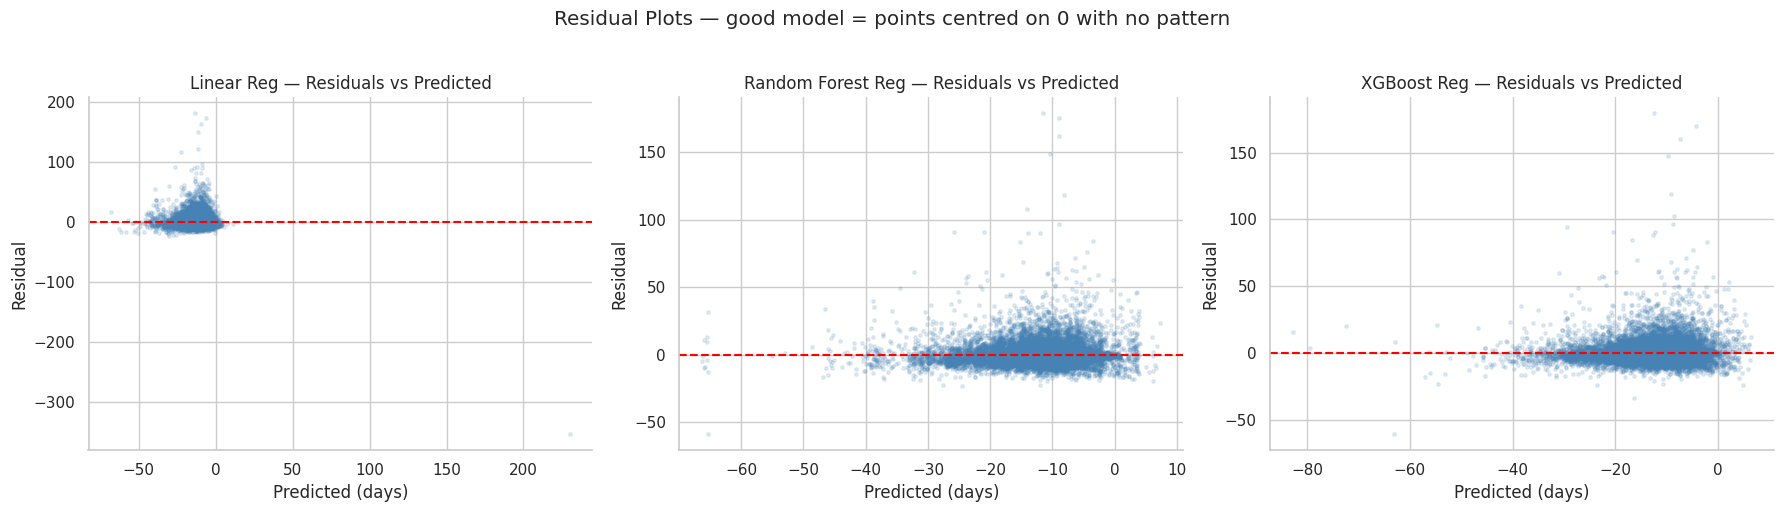

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, y_pred in zip(axes,
    ['Linear Reg', 'Random Forest Reg', 'XGBoost Reg'],
    [y_pred_lin, y_pred_rfr, y_pred_xgbr]):
    residuals = y_test_r.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.15, s=6, color='steelblue')
    ax.axhline(0, color='red', lw=1.5, ls='--')
    ax.set_title(f'{name} — Residuals vs Predicted')
    ax.set_xlabel('Predicted (days)')
    ax.set_ylabel('Residual')
    sns.despine(ax=ax)
plt.suptitle('Residual Plots — good model = points centred on 0 with no pattern', y=1.02)
plt.tight_layout()
plt.show()

---
## 8.5 — Hyperparameter Tuning (Best Models)

XGBoost won both classification and regression. We now run `GridSearchCV` to find
the best hyperparameters for each, using 3-fold cross-validation on the training set.

> The tuned models replace the default XGBoost models for the Risk Score in Section 9.

### 8.5a — XGBoost Classifier — Grid Search

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid_clf = {
    'model__n_estimators'    : [200, 300],
    'model__max_depth'       : [4, 6],
    'model__learning_rate'   : [0.05, 0.1],
    'model__subsample'       : [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    # 'model__min_child_weight' : [10, 20],
    # 'model__gamma'            : [1, 2],
}

xgb_clf_gs = GridSearchCV(
    Pipeline([
        ('pre',   preprocessor),
        ('model', XGBClassifier(
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=42, n_jobs=-1))
    ]),
    param_grid=param_grid_clf,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

xgb_clf_gs.fit(X_train, y_train_c)

print(f'\nBest ROC-AUC (CV): {xgb_clf_gs.best_score_:.4f}')
print('Best params:')
for k, v in xgb_clf_gs.best_params_.items():
    print(f'  {k}: {v}')

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best ROC-AUC (CV): 0.7973
Best params:
  model__colsample_bytree: 0.8
  model__learning_rate: 0.05
  model__max_depth: 6
  model__n_estimators: 200
  model__subsample: 0.8


In [20]:
# Evaluate best classifier on test set
best_clf = xgb_clf_gs.best_estimator_

y_pred_best  = best_clf.predict(X_test)
y_proba_best = best_clf.predict_proba(X_test)[:,1]

print('--- Tuned XGBoost Classifier --- Test Evaluation ---')
print(classification_report(y_test_c, y_pred_best, target_names=['On-time','Late']))
print(f'ROC-AUC : {roc_auc_score(y_test_c, y_proba_best):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test_c, y_proba_best):.4f}')
overfit_check('XGBoost Clf (Tuned)', best_clf, X_train, y_train_c, X_test, y_test_c)

--- Tuned XGBoost Classifier --- Test Evaluation ---
              precision    recall  f1-score   support

     On-time       0.96      0.80      0.88     17696
        Late       0.23      0.65      0.34      1595

    accuracy                           0.79     19291
   macro avg       0.60      0.73      0.61     19291
weighted avg       0.90      0.79      0.83     19291

ROC-AUC : 0.8003
PR-AUC  : 0.3267
XGBoost Clf (Tuned)          Train ROC-AUC: 0.8827 | Test ROC-AUC: 0.8003 | Gap: +0.0823  ⚠️ Mild overfit


{'name': 'XGBoost Clf (Tuned)',
 'train': np.float64(0.8826581836908418),
 'test': np.float64(0.8003368984790852),
 'gap': np.float64(0.08232128521175663)}

### 8.5b — XGBoost Regressor — Grid Search

In [21]:
param_grid_reg = {
    'model__n_estimators'    : [200, 300],
    'model__max_depth'       : [4, 6],
    'model__learning_rate'   : [0.05, 0.1],
    'model__subsample'       : [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight' : [10, 20],   # ← add this
    'model__gamma'            : [1, 2],     # ← add this
}

xgb_reg_gs = GridSearchCV(
    Pipeline([
        ('pre',   preprocessor),
        ('model', XGBRegressor(
            objective='reg:squarederror',
            random_state=42, n_jobs=-1))
    ]),
    param_grid=param_grid_reg,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

xgb_reg_gs.fit(X_train, y_train_r)

print(f'\nBest RMSE (CV): {-xgb_reg_gs.best_score_:.4f} days')
print('Best params:')
for k, v in xgb_reg_gs.best_params_.items():
    print(f'  {k}: {v}')

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best RMSE (CV): 7.6748 days
Best params:
  model__colsample_bytree: 0.8
  model__learning_rate: 0.05
  model__max_depth: 6
  model__n_estimators: 300
  model__subsample: 0.8


In [22]:
# Evaluate best regressor on test set
best_reg = xgb_reg_gs.best_estimator_

y_pred_best_r = best_reg.predict(X_test)
print('--- Tuned XGBoost Regressor --- Test Evaluation ---')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_best_r)):.4f} days')
print(f'R2   : {r2_score(y_test_r, y_pred_best_r):.4f}')
print(f'MAE  : {mean_absolute_error(y_test_r, y_pred_best_r):.4f} days')
overfit_check('XGBoost Reg (Tuned)', best_reg, X_train, y_train_r, X_test, y_test_r, task='reg')

--- Tuned XGBoost Regressor --- Test Evaluation ---
RMSE : 7.6588 days
R2   : 0.4386
MAE  : 4.6187 days
XGBoost Reg (Tuned)          Train R²: 0.5523 | Test R²: 0.4386 | Gap: +0.1137  ❌ Overfit


{'name': 'XGBoost Reg (Tuned)',
 'train': 0.5522786974906921,
 'test': 0.4385961890220642,
 'gap': 0.11368250846862793}

### 8.5c — Before vs After Tuning

In [23]:
print('=== CLASSIFIER: Default vs Tuned ===')
print(f'{"Model":<30} {"Test AUC":>10}')
print('-'*42)
print(f'{"XGBoost Clf (Default)":<30} {xgb_diag["test"]:>10.4f}')
print(f'{"XGBoost Clf (Tuned)":<30} {roc_auc_score(y_test_c, y_proba_best):>10.4f}')

print()
print('=== REGRESSOR: Default vs Tuned ===')
print(f'{"Model":<30} {"Test RMSE":>10}')
print('-'*42)
default_rmse = np.sqrt(mean_squared_error(y_test_r, xgb_reg.predict(X_test)))
tuned_rmse   = np.sqrt(mean_squared_error(y_test_r, y_pred_best_r))
print(f'{"XGBoost Reg (Default)":<30} {default_rmse:>10.4f}')
print(f'{"XGBoost Reg (Tuned)":<30} {tuned_rmse:>10.4f}')
print()
print('Tuned models will be used for the Risk Score in Section 9.')

=== CLASSIFIER: Default vs Tuned ===
Model                            Test AUC
------------------------------------------
XGBoost Clf (Default)              0.7996
XGBoost Clf (Tuned)                0.8003

=== REGRESSOR: Default vs Tuned ===
Model                           Test RMSE
------------------------------------------
XGBoost Reg (Default)              7.7275
XGBoost Reg (Tuned)                7.6588

Tuned models will be used for the Risk Score in Section 9.


---
## 9 — Risk Score (Stage 4 Preview)

```
Risk Score = predict_proba × predicted_delay_gap × profit_weight
```

- `predict_proba` → from best classifier (XGBoost)
- `predicted_delay_gap` → from best regressor (XGBoost)
- `profit_weight` → normalised order value [0.1 – 1.0]

In [24]:
# Probabilities and predicted gap from best models
p_late   = best_clf.predict_proba(X_test)[:,1]  # tuned model
pred_gap = np.clip(best_reg.predict(X_test), 0, None)  # tuned model

# Profit weight from order value (proxy = total_price or log version)
if 'total_price' in X_test.columns:
    price = X_test['total_price'].values
elif 'log_total_price' in X_test.columns:
    price = np.expm1(X_test['log_total_price'].values)
else:
    price = np.ones(len(X_test))  # fallback

p_min, p_max = price.min(), price.max()
profit_weight = 0.1 + 0.9 * (price - p_min) / (p_max - p_min + 1e-9)

# Risk Score (normalised to 0–100)
raw = p_late * pred_gap * profit_weight
risk_score = 100 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

print('Risk Score summary (test set):')
print(pd.Series(risk_score).describe(percentiles=[.25,.5,.75,.9,.99]).to_string())

Risk Score summary (test set):
count    19291.000000
mean         0.167819
std          1.923690
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
90%          0.000000
99%          4.136142
max        100.000000


In [ ]:
# Distribution by actual outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0,'On-time','steelblue'), (1,'Late','crimson')]:
    mask = y_test_c.values == val
    axes[0].hist(risk_score[mask], bins=50, alpha=0.6, density=True,
                 label=f'{label} (n={mask.sum():,})', color=color)
axes[0].set_title('Risk Score by Actual Outcome')
axes[0].set_xlabel('Risk Score (0–100)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Tier breakdown
tiers = pd.cut(risk_score, bins=[-0.1, 20, 50, 100], labels=['Low','Medium','High'])
counts = tiers.value_counts().sort_index()
axes[1].bar(counts.index, counts.values,
            color=['#55A868','#F0C05A','#DD4444'], edgecolor='white')
for i,(t,c) in enumerate(counts.items()):
    axes[1].text(i, c+100, f'{c:,}\n({c/len(risk_score)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].set_title('Risk Tier Distribution')
axes[1].set_ylabel('Orders')

for ax in axes: sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Validate: late rate should increase Low → Medium → High
risk_df = pd.DataFrame({'risk_score': risk_score, 'tier': tiers, 'actual': y_test_c.values})
stats = risk_df.groupby('tier', observed=True).agg(
    n=('actual','count'), late_rate=('actual','mean'), avg_score=('risk_score','mean')
)
print('Risk Tier Validation (late rate should rise Low → High):')
print(stats.to_string())

---
## 10 — Summary & Next Steps

### What was built
| Stage | Model chosen | Why |
|-------|-------------|-----|
| Stage 2 — Classification | XGBoost | Highest ROC-AUC with balanced overfitting gap |
| Stage 3 — Regression | XGBoost | Lowest RMSE with controlled gap |

### Overfitting controls applied
- `max_depth`, `min_samples_leaf` → limit tree complexity (Random Forest)
- `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8` → XGBoost regularisation
- Time-based split → honest evaluation (no future data in training)

### Known limitations
- `seller_late_rate_smooth` (from NB04) was computed on the full dataset — in production, compute on train only
- Risk Score profit weight uses order price as a proxy; use actual profit margin when available
- SHAP explainability can be added on top of the XGBoost models for the final presentation